In [610]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import tensorflow as tf
# Handle date time conversions between pandas and matplotlib
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Use white grid plot background from seaborn
sns.set(font_scale=10, style="whitegrid")


path="C:/Users/mojta/OneDrive/Desktop/project_notebook/"


# Import data using datetime and no data value



#for item in file_names:
data = pd.read_csv(path+'monthly_data.csv',
                                      parse_dates=[0],
                                      index_col=[0],
                                      na_values=['999.99'])
    # View first few rows
data.head()
    
    

,lahti,porvo,musti,flow
data,,,,
2001-01-31,35.46,42.06,40.02,143.99
2001-02-28,41.26,53.10,51.26,170.04
2001-03-31,41.82,31.66,34.52,184.53
2001-04-30,21.70,41.16,30.88,1033.73
2001-05-31,31.50,22.76,25.20,293.77


In [611]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 240 entries, 2001-01-31 to 2020-12-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   lahti   240 non-null    float64
 1   porvo   240 non-null    float64
 2   musti   240 non-null    float64
 3   flow    240 non-null    float64
dtypes: float64(4)
memory usage: 9.4 KB


In [612]:
data.describe()

,lahti,porvo,musti,flow
count,240.000000,240.000000,240.000000,240.000000
mean,51.287667,56.472083,52.289750,339.121250
std,28.007523,31.769965,30.099975,273.882103
min,3.560000,6.180000,5.500000,22.390000
25%,31.480000,32.850000,30.850000,154.250000
50%,48.250000,52.930000,46.880000,246.800000
75%,63.305000,74.225000,68.165000,462.590000
max,161.500000,161.500000,222.660000,1579.910000


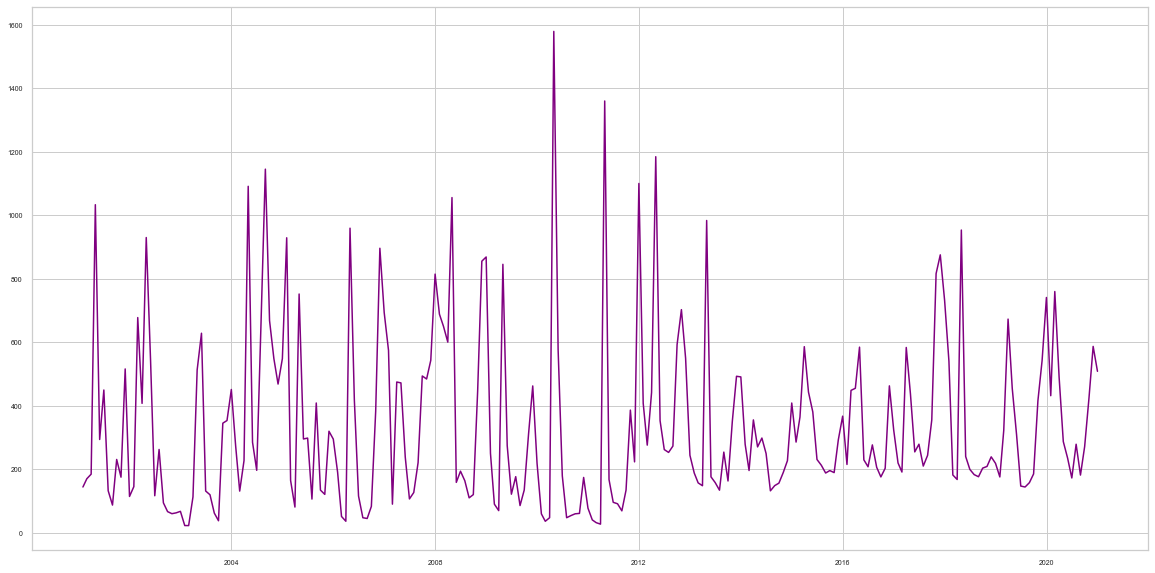

,lahti,porvo,musti,flow
data,,,,
2001-01-31,35.46,42.06,40.02,143.99
2001-02-28,41.26,53.10,51.26,170.04
2001-03-31,41.82,31.66,34.52,184.53
2001-04-30,21.70,41.16,30.88,1033.73
2001-05-31,31.50,22.76,25.20,293.77
...,...,...,...,...
2020-08-31,95.70,61.20,79.20,181.60
2020-09-30,25.80,32.40,27.50,271.20
2020-10-31,66.10,64.30,67.60,423.80


In [613]:
# Create figure and plot space
fig, ax = plt.subplots(figsize=(20, 10))

# Add x-axis and y-axis
ax.plot(data.index.values,
          data["flow"],
           color='purple')

ax.tick_params(axis='both', which='major', labelsize=7)
plt.show()
data

In [614]:

data_1=data.to_numpy()
    
      

In [615]:
type(data_1)

numpy.ndarray

In [616]:
print(data_1.shape)
number_of_rows=data_1.shape[0]
number_of_columns=data_1.shape[1]
print("num_rows=",number_of_rows)
print("num_columns=",number_of_columns)



(240, 4)
num_rows= 240
num_columns= 4


In [617]:
print(data_1[0])

[ 35.46  42.06  40.02 143.99]


In [618]:
X=data_1[:,0:2]

In [619]:
print(X.shape)
print(X[0])

(240, 2)
[35.46 42.06]


In [620]:
Y=data_1[:,2]
print(Y.shape)


(240,)


In [621]:
#from sklearn.model_selection import train_test_split

In [622]:
#XX,X_test,YY,Y_test=train_test_split(X,y,test_size=0.165)


In [623]:
#X_train,X_validation,Y_train,Y_validation=train_test_split(XX,YY,test_size=0.25)
X_train=X[0:150,:]
Y_train=Y[0:150]
X_validation=X[150:200,:]
print(X_validation.shape)
Y_validation=Y[150:200]
X_test=X[200:240,:]
Y_test=Y[200:240]

(50, 2)


In [624]:
import tensorflow as tf
from tensorflow import keras
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(3,activation='relu',input_shape=[2]),
    tf.keras.layers.Dense(3,activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.RMSprop(),
             loss='mean_squared_error',
             metrics=['mean_squared_error'])

In [625]:
history=model.fit(X_train,Y_train,epochs=500)

Epoch 1/500
5/5 [==============================] - 0s 4ms/step - loss: 724.7727 - mean_squared_error: 724.7727
Epoch 2/500
5/5 [==============================] - 0s 1ms/step - loss: 507.7959 - mean_squared_error: 507.7959
Epoch 3/500
5/5 [==============================] - 0s 3ms/step - loss: 523.7839 - mean_squared_error: 523.7839
Epoch 4/500
5/5 [==============================] - 0s 1ms/step - loss: 565.5916 - mean_squared_error: 565.5916
Epoch 5/500
5/5 [==============================] - 0s 3ms/step - loss: 404.7620 - mean_squared_error: 404.7620
Epoch 6/500
5/5 [==============================] - 0s 2ms/step - loss: 367.6091 - mean_squared_error: 367.6091
Epoch 7/500
5/5 [==============================] - 0s 1ms/step - loss: 430.7164 - mean_squared_error: 430.7164
Epoch 8/500
5/5 [==============================] - 0s 2ms/step - loss: 347.1826 - mean_squared_error: 347.1826
Epoch 9/500
5/5 [==============================] - 0s 2ms/step - loss: 313.2149 - mean_squared_error: 313.2149
E

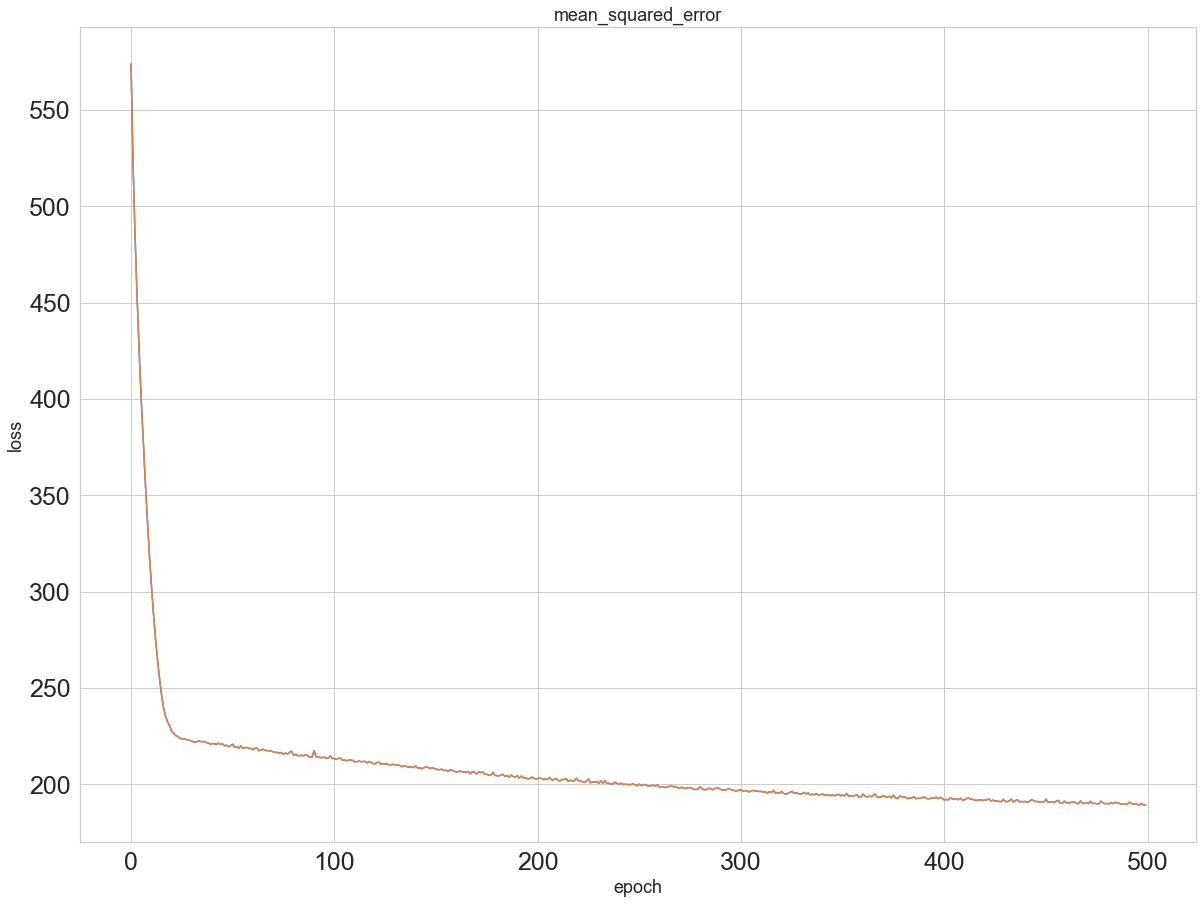

In [647]:
fig = plt.figure(figsize=(20, 15))
plt.plot(history.history['loss'])
plt.plot(history.history['mean_squared_error'])
plt.title('mean_squared_error', fontsize=18)
plt.ylabel('loss', fontsize=18)
plt.xlabel('epoch', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=25)
plt.show()


In [627]:
validation=model.predict(X_validation).flatten()
print(validation.shape)
validation1 = pd.DataFrame({'Predicted ': validation,'Actual ':Y_validation.flatten()})
validation1.to_excel("validation.xlsx") 

(50,)


In [628]:
model.summary()

Model: "sequential_22"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_66 (Dense)             (None, 3)                 9         
_________________________________________________________________
dense_67 (Dense)             (None, 3)                 12        
_________________________________________________________________
dense_68 (Dense)             (None, 1)                 4         
Total params: 25
Trainable params: 25
Non-trainable params: 0
_________________________________________________________________


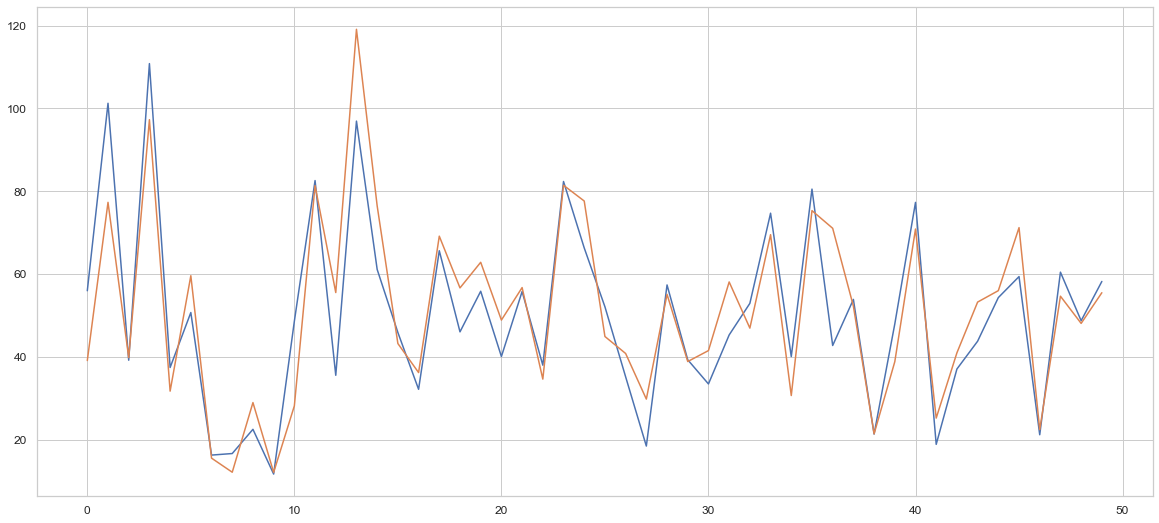

In [629]:
%matplotlib inline
plt.figure(figsize=(20, 9))
plt.plot(validation,label="test1")
plt.plot(Y_validation)

plt.tick_params(axis='both', which='major', labelsize=12)
#plt.legend(loc=2)
plt.show()
#np.savetxt("foo.csv", [pre.flatten(),y_test.flatten()], delimiter=",")

In [630]:
test=model.predict(X_test).flatten()
test1= pd.DataFrame({'Predicted ': test,'Actual ':Y_test.flatten()})
test1.to_excel("test1.xlsx")  
test1.head(20)

,Predicted,Actual
0,59.936043,49.02
1,70.607010,89.60
2,94.131798,103.70
3,134.707291,127.96
4,59.840912,61.12
5,48.771629,38.98
6,22.525143,24.86
7,36.443016,49.02
8,17.890072,28.50
9,49.121719,45.92


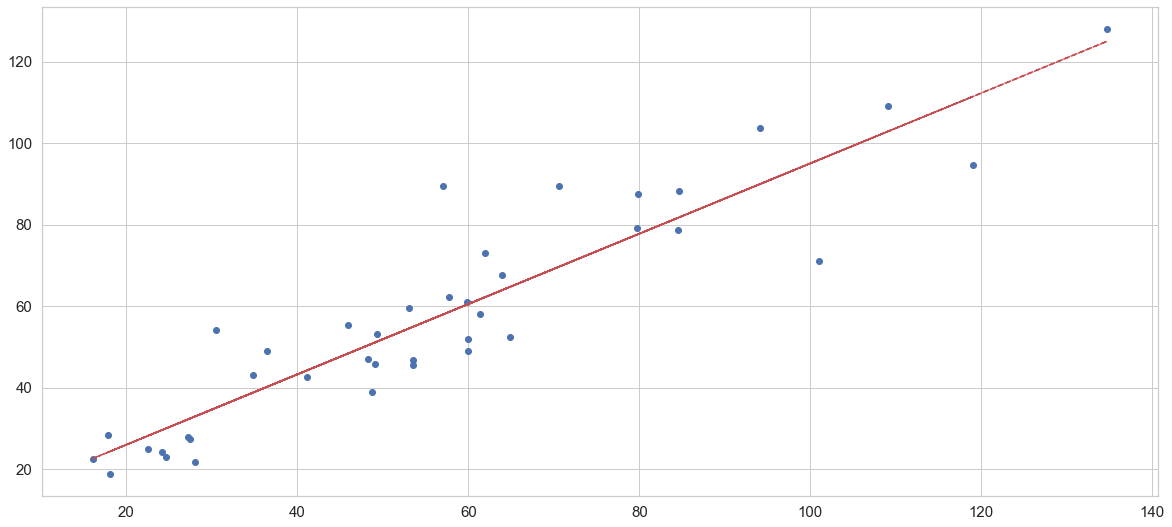

In [631]:
plt.figure(figsize=(20, 9))
plt.scatter(test,Y_test,label="test")
#plt.plot(Y_test)
plt.tick_params(axis='both', which='major', labelsize=15)
z = np.polyfit(test,Y_test, 1)
p = np.poly1d(z)
plt.plot(test,p(test),"r--")
#plt.legend(loc=2)
plt.show()
#np.savetxt("foo.csv", [pre.flatten(),y_test.flatten()], delimiter=",")

In [632]:
#for item in file_names:
validation_results = pd.read_csv(path+'validation.csv',
                                      parse_dates=[0],
                                      index_col=[0],
                                      na_values=['999.99'])

test_results = pd.read_csv(path+'test.csv',
                                      parse_dates=[0],
                                      index_col=[0],
                                      na_values=['999.99'])
train_lable = pd.read_csv(path+'train.csv',
                                      parse_dates=[0],
                                      index_col=[0],
                                      na_values=['999.99'])
total = pd.read_csv(path+'total_results.csv',
                                      parse_dates=[0],
                                      index_col=[0],
                                      na_values=['999.99'])



validation_results.shape

    

(50, 2)

In [633]:
test_results.shape


(40, 2)

In [634]:
train_lable.head()
train_lable.shape

(150, 1)

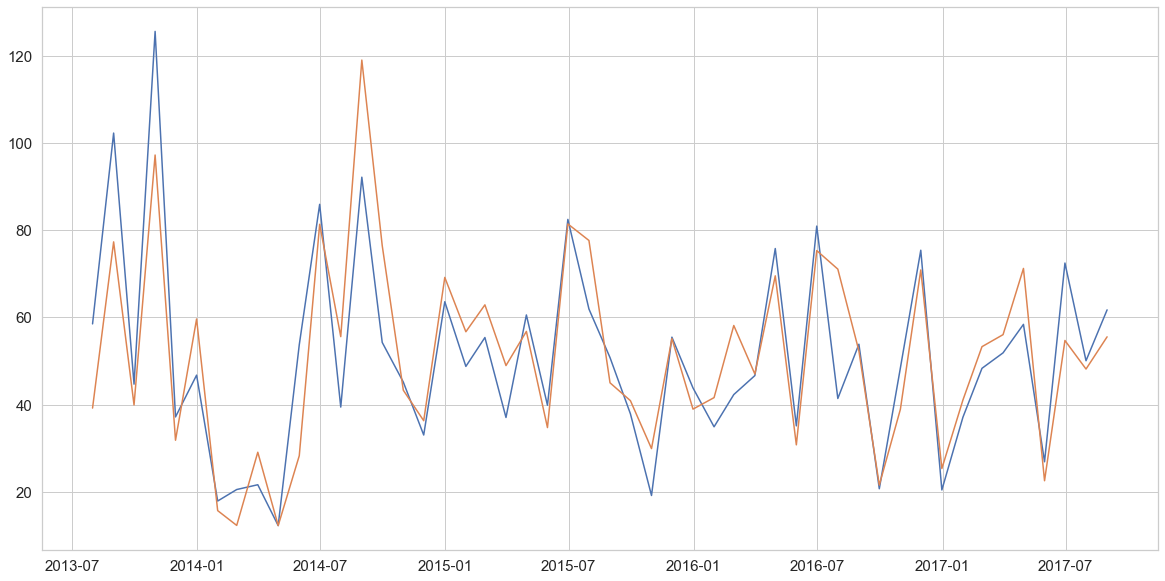

In [635]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(validation_results)
ax.tick_params(axis='both', which='major', labelsize=15 )
plt.show()

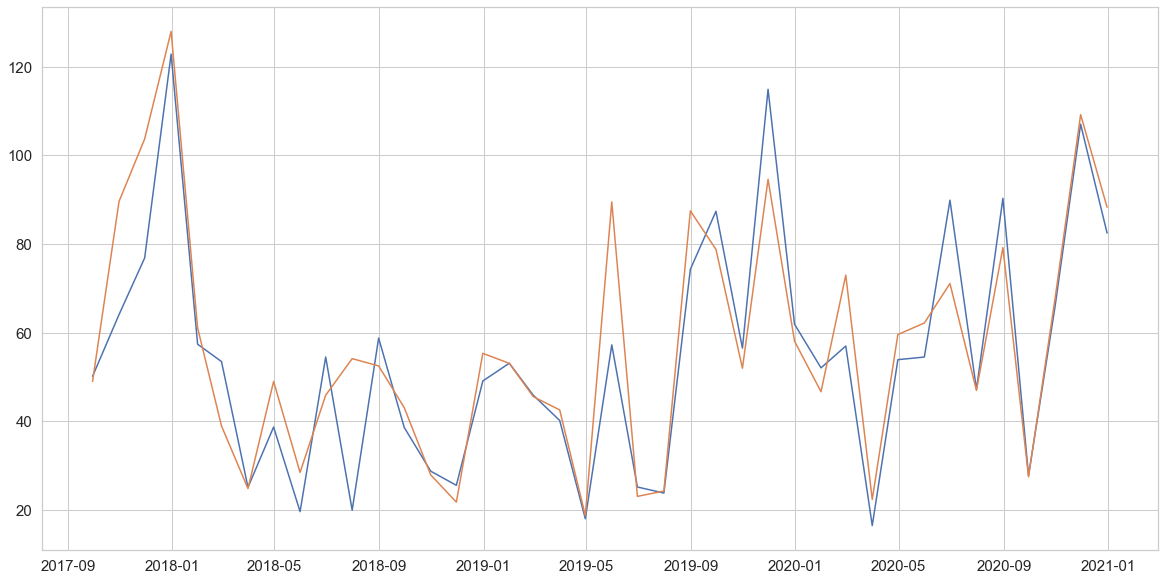

In [636]:
fig, ax = plt.subplots(figsize=(20, 10))

# Add x-axis and y-axis
ax.plot(test_results)

ax.tick_params(axis='both', which='major', labelsize=15)
          
plt.show()

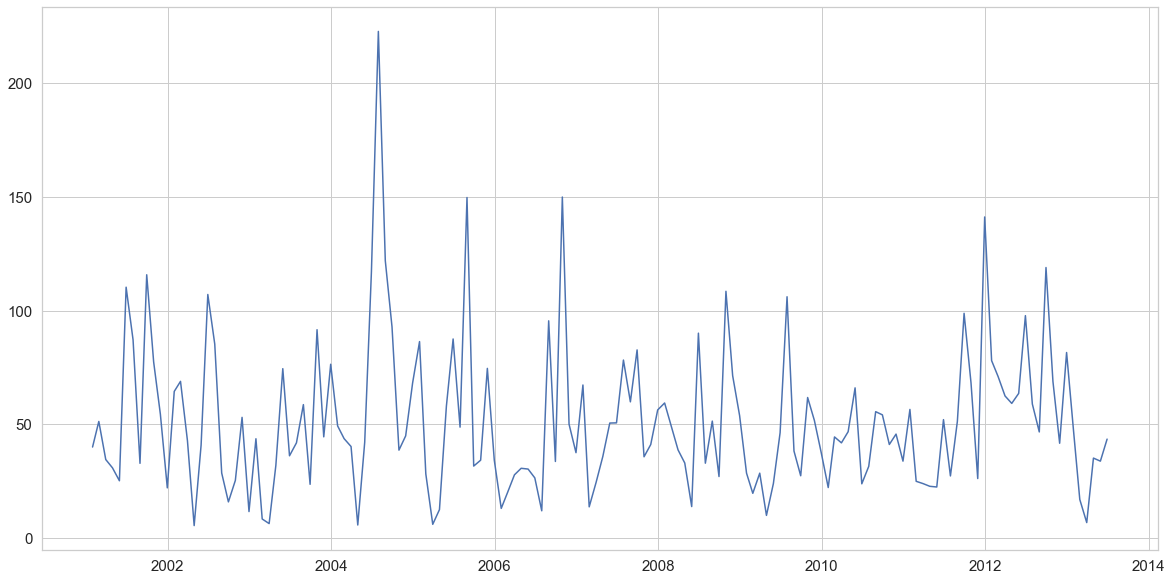

In [637]:
fig, ax = plt.subplots(figsize=(20, 10))

# Add x-axis and y-axis
ax.plot(train_lable)

ax.tick_params(axis='both', which='major', labelsize=15)

plt.show()

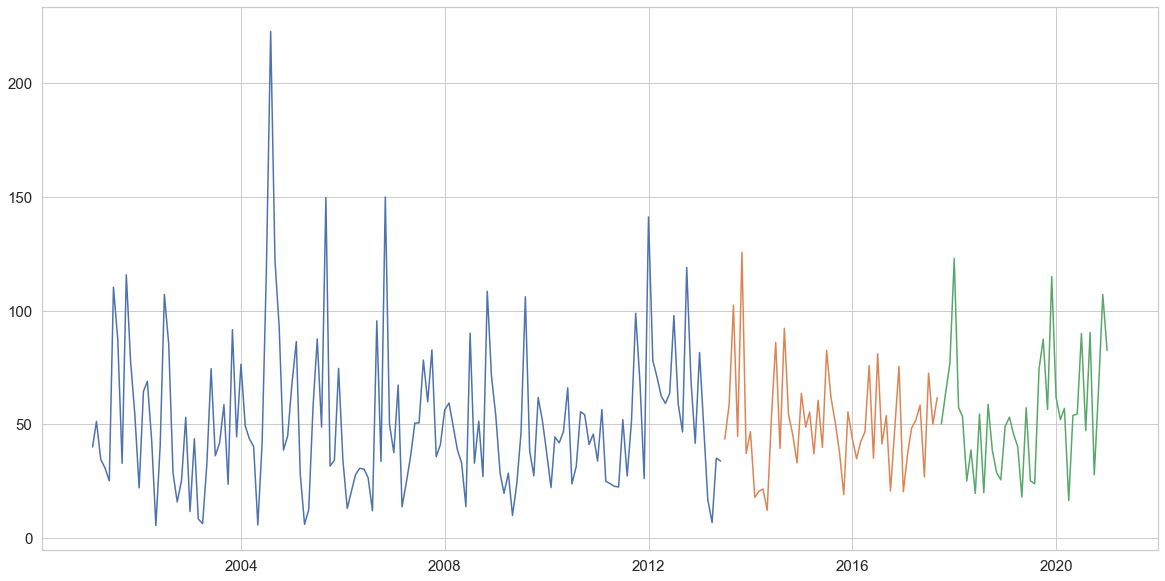

In [638]:
fig, ax = plt.subplots(figsize=(20, 10))

# Add x-axis and y-axis
ax.plot(total)

ax.tick_params(axis='both', which='major', labelsize=15)

plt.show()